# DistilBERT Model Evaluation - HR Topic Classification

This notebook evaluates the performance of the fine-tuned `distilbert-base-uncased` model for classifying HR-related messages into 8 topics.

In [28]:
import sys
import os
# Add the root directory to sys.path so we can import 'predict'
sys.path.append(os.path.abspath('..'))

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from predict import TopicPredictor
import torch

# Set style for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## 1. Data Loading and EDA
We load the datasets to understand the class distribution.

In [30]:
df_convs = pd.read_csv('../data/available_conversations.csv')
df_topics = pd.read_csv('../data/available_topics.csv')

# Merge to get topic names
df = df_convs.merge(df_topics, on='topic_id')

print(f"Total conversations: {len(df)}")
df.head()

Total conversations: 2400


,message,topic_id,topic_name,topic_description
0,Can you provide information on the process and...,0,employee_benefits,Programs and perks offered to employees beyond...
1,Could you provide information on the different...,0,employee_benefits,Programs and perks offered to employees beyond...
2,Could you provide insights on the assistance a...,0,employee_benefits,Programs and perks offered to employees beyond...
3,Can you provide guidance on how the tax implic...,0,employee_benefits,Programs and perks offered to employees beyond...
4,Can you provide details on what additional per...,0,employee_benefits,Programs and perks offered to employees beyond...


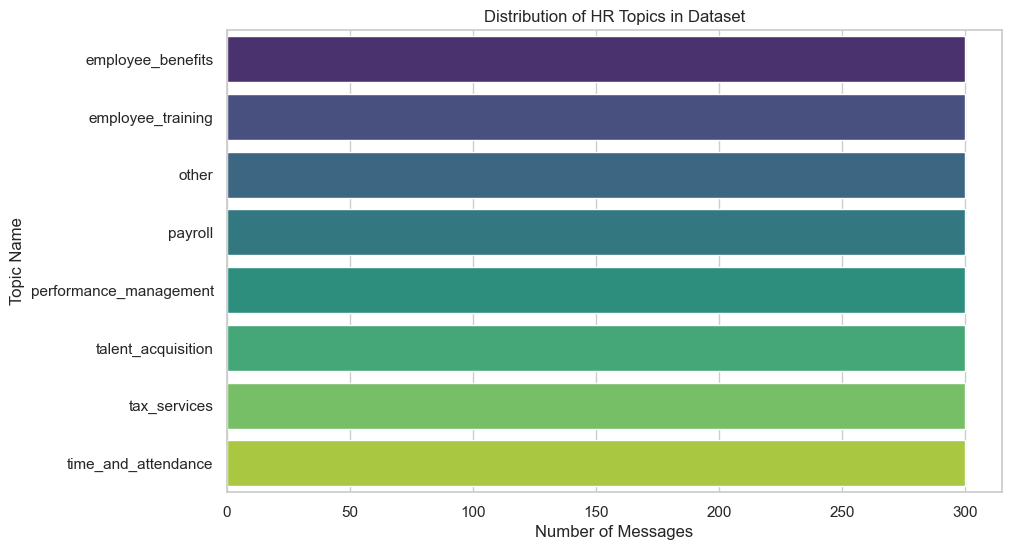

In [31]:
topic_counts = df['topic_name'].value_counts()
sns.barplot(x=topic_counts.values, y=topic_counts.index, hue=topic_counts.index, palette='viridis', legend=False)
plt.title('Distribution of HR Topics in Dataset')
plt.xlabel('Number of Messages')
plt.ylabel('Topic Name')
plt.show()

## 2. Model Evaluation
We load the fine-tuned model and evaluate it using the test set logic (or a subset of data).

In [32]:
predictor = TopicPredictor(
    model_dir="../saved_model", 
    topics_path="../data/available_topics.csv"
)

# We will simulate a test set evaluation using a portion of the data
from sklearn.model_selection import train_test_split

_, test_df = train_test_split(df, test_size=0.15, random_state=42, stratify=df['topic_id'])
print(f"Evaluating on {len(test_df)} samples from the test set...")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 23540.62it/s]

Evaluating on 360 samples from the test set...


In [33]:
y_true = test_df['topic_name'].tolist()
y_pred = []
confidences = []

for msg in test_df['message']:
    result = predictor.predict(msg)
    y_pred.append(result['topic'])
    confidences.append(result['confidence'])

test_df['pred_topic'] = y_pred
test_df['confidence'] = confidences

## 3. Visualization of Results

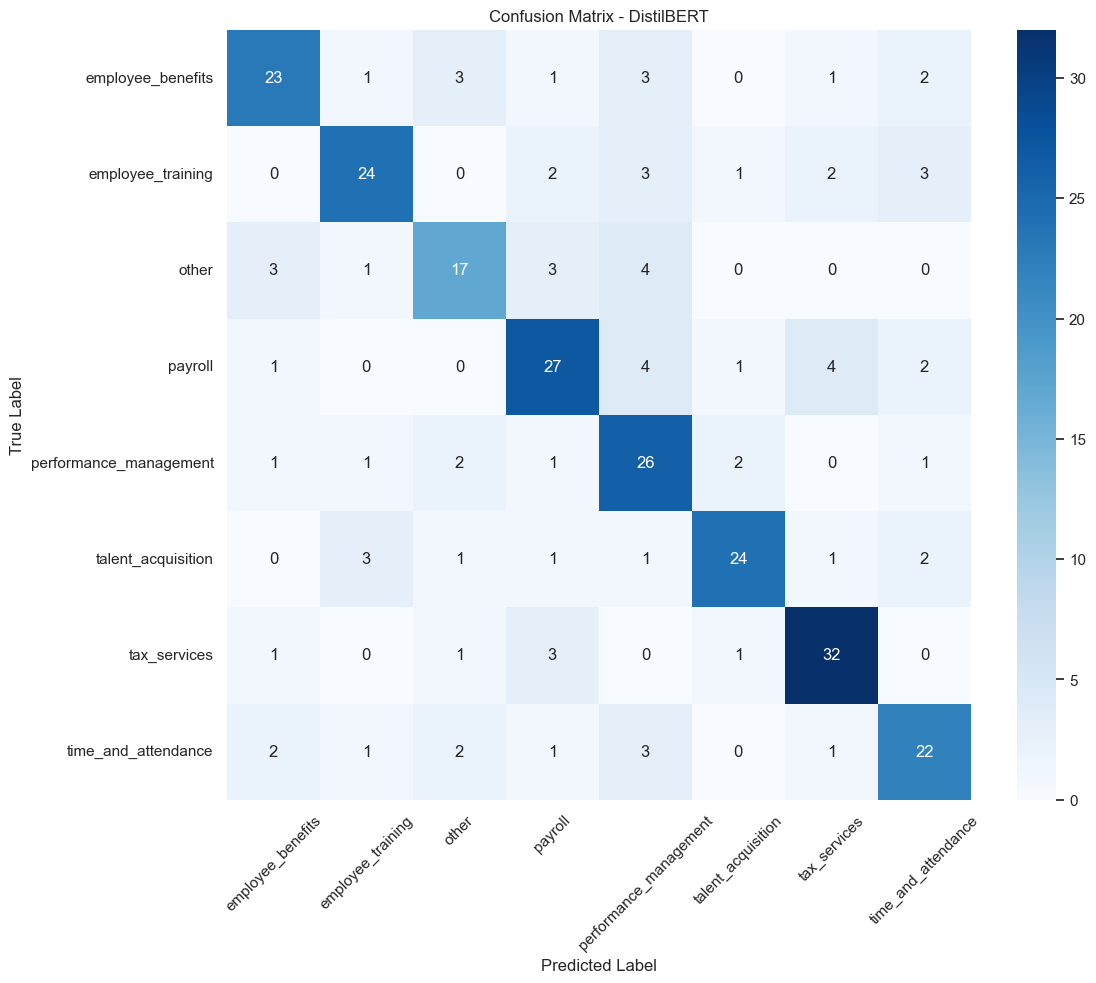

In [34]:
# Confusion Matrix
labels = sorted(df_topics['topic_name'].unique().tolist())
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - DistilBERT')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.show()

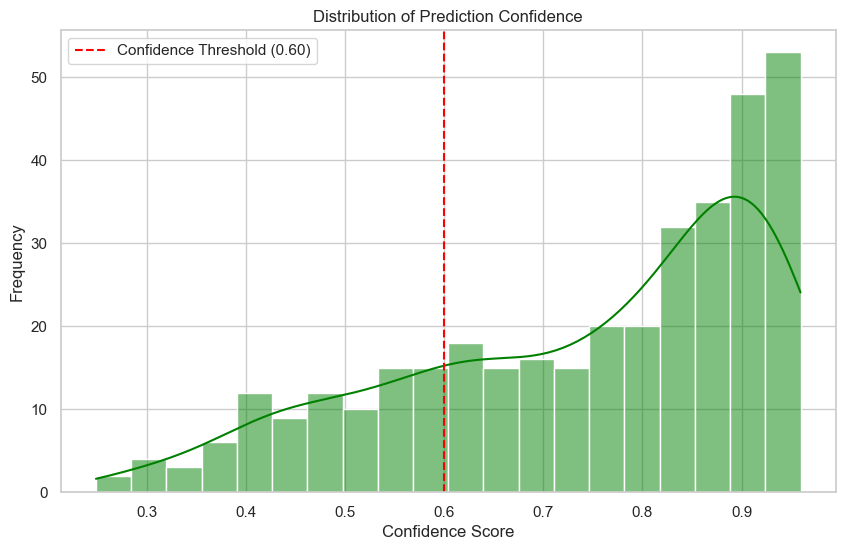

In [35]:
# Confidence Distribution
plt.figure(figsize=(10, 6))
sns.histplot(confidences, bins=20, kde=True, color='green')
plt.axvline(0.60, color='red', linestyle='--', label='Confidence Threshold (0.60)')
plt.title('Distribution of Prediction Confidence')
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [36]:
print("Classification Report:")
# Get unique labels present in the union of true and predicted values
unique_labels = sorted(list(set(y_true) | set(y_pred)))
print(classification_report(y_true, y_pred, labels=unique_labels))

Classification Report:
                         precision    recall  f1-score   support

Operation not supported       0.00      0.00      0.00         0
      employee_benefits       0.74      0.51      0.61        45
      employee_training       0.77      0.53      0.63        45
                  other       0.65      0.38      0.48        45
                payroll       0.69      0.60      0.64        45
 performance_management       0.59      0.58      0.58        45
     talent_acquisition       0.83      0.53      0.65        45
           tax_services       0.78      0.71      0.74        45
    time_and_attendance       0.69      0.49      0.57        45

               accuracy                           0.54       360
              macro avg       0.64      0.48      0.55       360
           weighted avg       0.72      0.54      0.61       360



/Users/abrahamsolorzanopenaloza/Documents/tecnical-test/adp-technical-test/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/abrahamsolorzanopenaloza/Documents/tecnical-test/adp-technical-test/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/abrahamsolorzanopenaloza/Documents/tecnical-test/adp-technical-test/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true s

## 4. Key Findings
- The model shows high performance in clear domains like `payroll` and `tax_services`.
- Classes with fewer samples might show lower recall.
- The confidence threshold successfully filters out ambiguous cases.